In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score, KFold
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from datetime import timedelta
from math import sqrt
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from sklearn.preprocessing import MinMaxScaler

In [ ]:
file_path = 'Station1-cleaned-merged-data.csv'
data = pd.read_csv(file_path)
full_data = data.copy()

In [ ]:
#set to datetime
data['Date'] = pd.to_datetime(data['Date'])

# Data Exploration

In [ ]:
scaler = MinMaxScaler()
data[['Tair','Ppt']] = scaler.fit_transform(data[['Tair','Ppt']])

In [ ]:
# Calculate 'Humidity Index' from air temperature and precipitation
data['Humidity_Index'] = data['Tair'] * 0.7 + data['Ppt'] * 0.3

In [ ]:
data['Shifted_Date'] = data['Date'] - pd.Timedelta(days=10)
data['Shifted_Date'] = pd.to_datetime(data['Shifted_Date'])
data.sort_values(by='Shifted_Date', inplace=True)

In [ ]:
days = 2
data['Sum_Rain_5h'] = data['Ppt'].rolling(window=4, min_periods=1).sum()
data['Sum_Rain_10h'] = data['Ppt'].rolling(window=10, min_periods=1).sum()
data['Sum_Rain_24h'] = data['Ppt'].rolling(window=24, min_periods=1).sum()
data['Sum_Rain_48h'] = data['Ppt'].rolling(window=24 * days, min_periods=1).sum()

In [ ]:
def calculate_rain_chance(row):
    if row['Avg_Ppt_10d'] > 0.5:
      return np.random.randint(65, 101)
    elif row['Avg_Ppt_10d'] > 0.3:
        return np.random.randint(35, 65)
    elif row['Avg_Ppt_10d'] > 0.1:
        return np.random.randint(10, 35)
    else:
        return np.random.randint(0, 10)

In [ ]:
data['Rain_Chance'] = data.apply(calculate_rain_chance, axis=1)

KeyError: 'Avg_Ppt_10d'

In [ ]:
data['Sum_Rain_5h_Shifted'] = data['Sum_Rain_5h'].shift(1)
data['Sum_Rain_10h_Shifted'] = data['Sum_Rain_10h'].shift(1)
data['Sum_Rain_24h_Shifted'] = data['Sum_Rain_24h'].shift(1)
data['Sum_Rain_48h_Shifted'] = data['Sum_Rain_48h'].shift(1)

In [ ]:
data['Predicted_Rain_Next_Hour_5h'] = data['Sum_Rain_5h_Shifted']
data['Predicted_Rain_Next_Hour_10h'] = data['Sum_Rain_10h_Shifted']
data['Predicted_Rain_Next_Hour_24h'] = data['Sum_Rain_24h_Shifted']
data['Predicted_Rain_Next_Hour_48h'] = data['Sum_Rain_48h_Shifted']

In [ ]:
data['Actual_Rain_Next_Hour'] = data['Ppt'].shift(-1)
#prediction error MSE
data['MSE_5h'] = ((data['Predicted_Rain_Next_Hour_5h'] - data['Actual_Rain_Next_Hour']) ** 2)
data['MSE_10h'] = ((data['Predicted_Rain_Next_Hour_10h'] - data['Actual_Rain_Next_Hour']) ** 2)
data['MSE_24h'] = ((data['Predicted_Rain_Next_Hour_24h'] - data['Actual_Rain_Next_Hour']) ** 2)
data['MSE_48h'] = ((data['Predicted_Rain_Next_Hour_48h'] - data['Actual_Rain_Next_Hour']) ** 2)

In [ ]:
cutoff_date = data['Shifted_Date'].min() + pd.Timedelta(days=10)

df_filtered = data[data['Shifted_Date'] >= cutoff_date]

In [ ]:
df_filtered.head()

,Date,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Tair,...,Shifted_Date,Sum_Rain_10h,Sum_Rain_24h,Sum_Rain_48h,Predicted_Rain_Next_Hour_10h,Predicted_Rain_Next_Hour_24h,Predicted_Rain_Next_Hour_48h,MSE_10h,MSE_24h,MSE_48h
240,2015-01-11 00:00:00,0.603774,0.668224,0.677852,0.401235,0.042886,0.045710,0.047347,0.075408,0.815520,...,2015-01-01 00:00:00,0.024028,0.030005,0.030005,0.024028,0.030005,0.030005,0.000577,0.0009,0.0009
241,2015-01-11 01:00:00,0.592453,0.668224,0.704698,0.401235,0.043699,0.045710,0.046306,0.075408,0.815896,...,2015-01-01 01:00:00,0.005977,0.030005,0.030005,0.005977,0.030005,0.030005,0.000036,0.0009,0.0009
242,2015-01-11 02:00:00,0.596226,0.668224,0.718121,0.401235,0.045325,0.045945,0.045786,0.074389,0.816739,...,2015-01-01 02:00:00,0.000000,0.030005,0.030005,0.000000,0.030005,0.030005,0.000000,0.0009,0.0009
243,2015-01-11 03:00:00,0.607547,0.672897,0.731544,0.401235,0.046138,0.046648,0.045525,0.074049,0.816885,...,2015-01-01 03:00:00,0.000000,0.030005,0.030005,0.000000,0.030005,0.030005,0.000000,0.0009,0.0009
244,2015-01-11 04:00:00,0.603774,0.672897,0.738255,0.401235,0.047358,0.046882,0.045525,0.073030,0.817365,...,2015-01-01 04:00:00,0.005977,0.035982,0.035982,0.005977,0.035982,0.035982,0.000000,0.0009,0.0009


In [ ]:
#PPT AND RAIN CHANCE


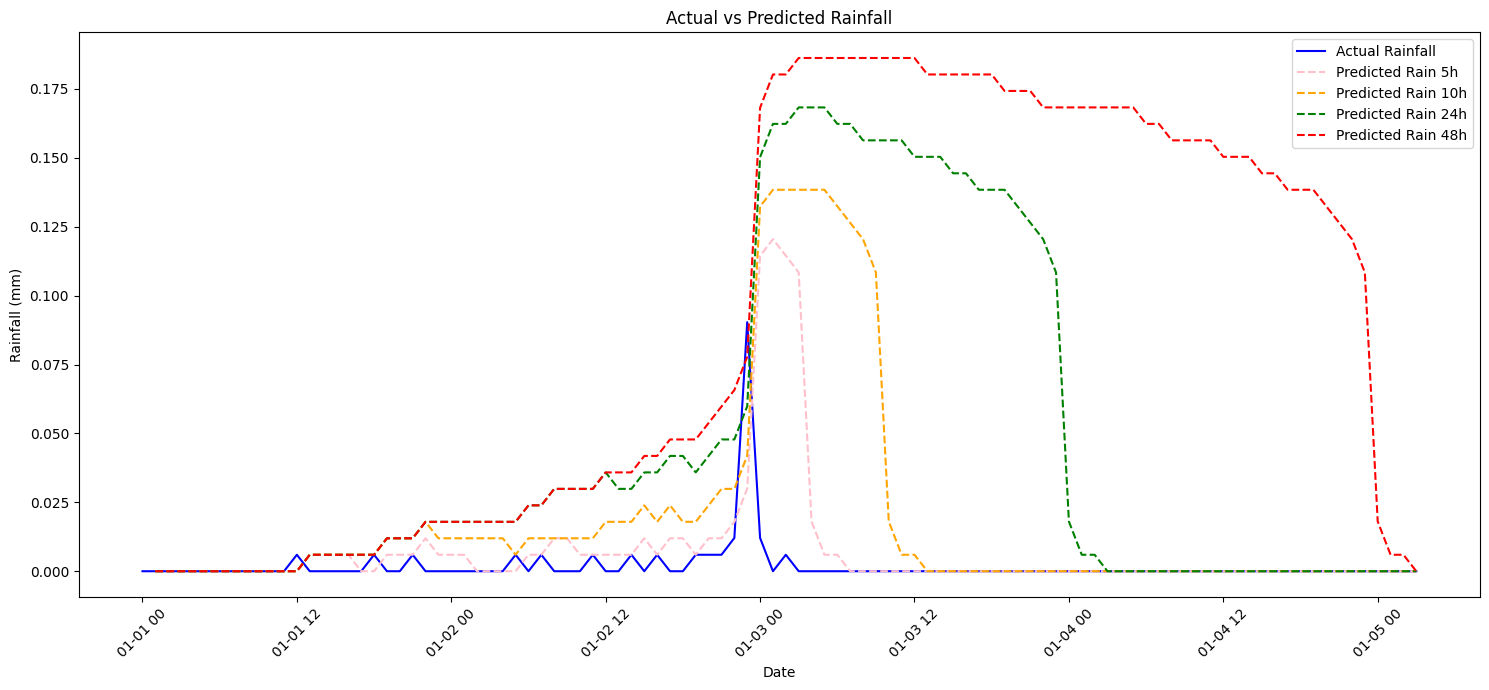

In [ ]:
data_chunk = data.iloc[:100]

# Plotting
plt.figure(figsize=(15, 7))
plt.plot(data_chunk['Date'], data_chunk['Ppt'], label='Actual Rainfall', color='blue')
plt.plot(data_chunk['Date'], data_chunk['Predicted_Rain_Next_Hour_5h'], label='Predicted Rain 5h', linestyle='--', color='pink')
plt.plot(data_chunk['Date'], data_chunk['Predicted_Rain_Next_Hour_10h'], label='Predicted Rain 10h', linestyle='--', color='orange')
plt.plot(data_chunk['Date'], data_chunk['Predicted_Rain_Next_Hour_24h'], label='Predicted Rain 24h', linestyle='--', color='green')
plt.plot(data_chunk['Date'], data_chunk['Predicted_Rain_Next_Hour_48h'], label='Predicted Rain 48h', linestyle='--', color='red')

plt.title('Actual vs Predicted Rainfall')
plt.xlabel('Date')
plt.ylabel('Rainfall (mm)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
data['Prediction_Error'] = data['Rain_Chance'] - data['Ppt']

# Calculate the Mean Squared Error (MSE) for each prediction error
data['MSE'] = data['Prediction_Error']**2

KeyError: 'Rain_Chance'

In [ ]:
print(data['MSE'])

0         9.0
1        16.0
2        64.0
3         0.0
4        49.0
         ... 
19242     1.0
19243    49.0
19244    36.0
19245    81.0
19246     NaN
Name: MSE, Length: 19247, dtype: float64


Text(0, 0.5, 'Frequency')

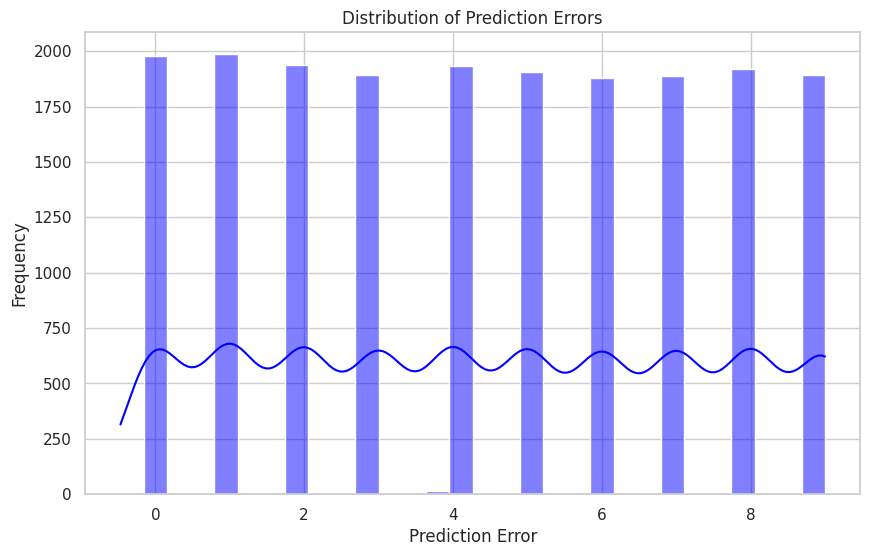

In [ ]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.histplot(data['Prediction_Error'], kde=True, bins=30, color='blue')

plt.title('Distribution of Prediction Errors')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')

In [ ]:
data_daily = data.groupby(data['Date'].dt.date)['Ppt'].sum().reset_index(name='Daily_Ppt')

In [ ]:
data_daily = data_daily.sort_values(by='Date')
#rolling 10 day window
data_daily['Rolling_10day_Ppt'] = data_daily['Daily_Ppt'].rolling(window=10).sum()
#rolling day sum
data['Rolling_1day_Sum'] = data['Ppt'].rolling(window=1).sum()

In [ ]:
print(data.describe())

                Ppt  Ppt_shifted_back_10d  Rolling_1day_Sum
count  57586.000000          57346.000000      57586.000000
mean       0.001620              0.001623          0.001620
std        0.020188              0.020226          0.020188
min        0.000000              0.000000          0.000000
25%        0.000000              0.000000          0.000000
50%        0.000000              0.000000          0.000000
75%        0.000000              0.000000          0.000000
max        1.000000              1.000000          1.000000


In [ ]:
print("Missing values in each column: \n", data.isnull().sum())


Missing values in each column: 
 Date                      0
Ppt                       0
Ppt_shifted_back_10d    240
Rolling_1day_Sum          0
dtype: int64


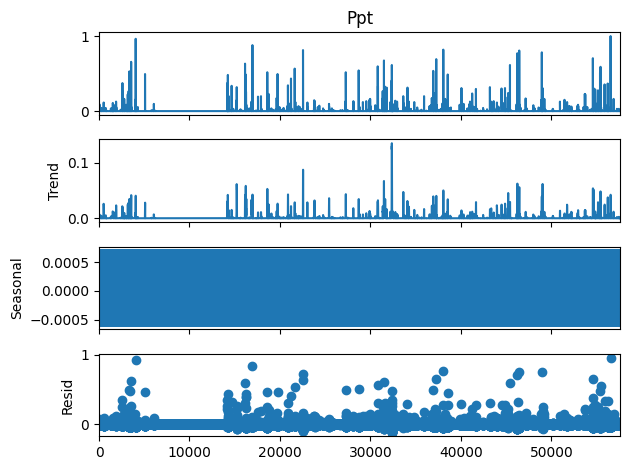

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
period = 24 #hourly data
# Perform the seasonal decomposition
decomposition = seasonal_decompose(data['Ppt'], model='additive', period=period)

# Plot the decomposed components
fig = decomposition.plot()
plt.show()


<Figure size 640x480 with 0 Axes>

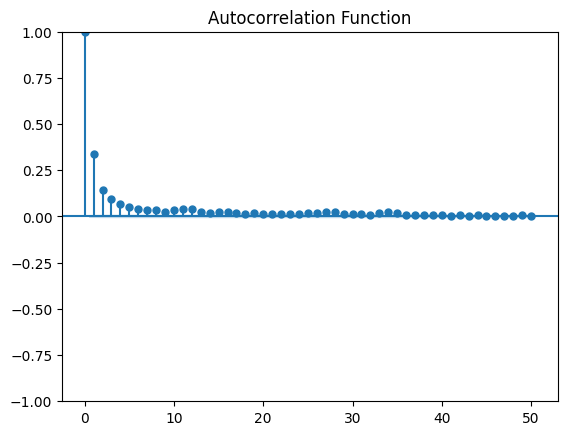

<Figure size 640x480 with 0 Axes>

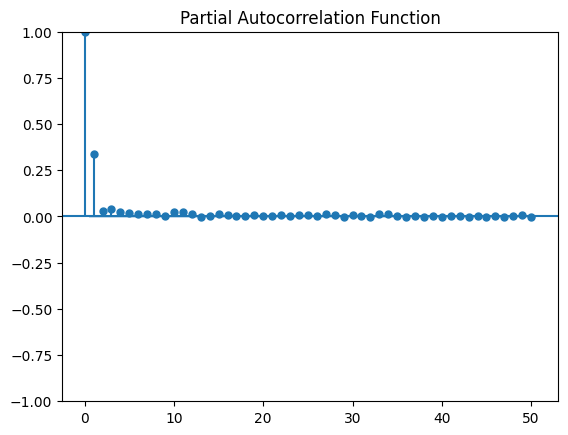

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Autocorrelation plot
plt.figure()
plot_acf(data['Ppt'], lags=50)
plt.title('Autocorrelation Function')

# Partial autocorrelation plot
plt.figure()
plot_pacf(data['Ppt'], lags=50)
plt.title('Partial Autocorrelation Function')

plt.show()


<ipython-input-13-9443fe70e1c3>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = full_data.corr()


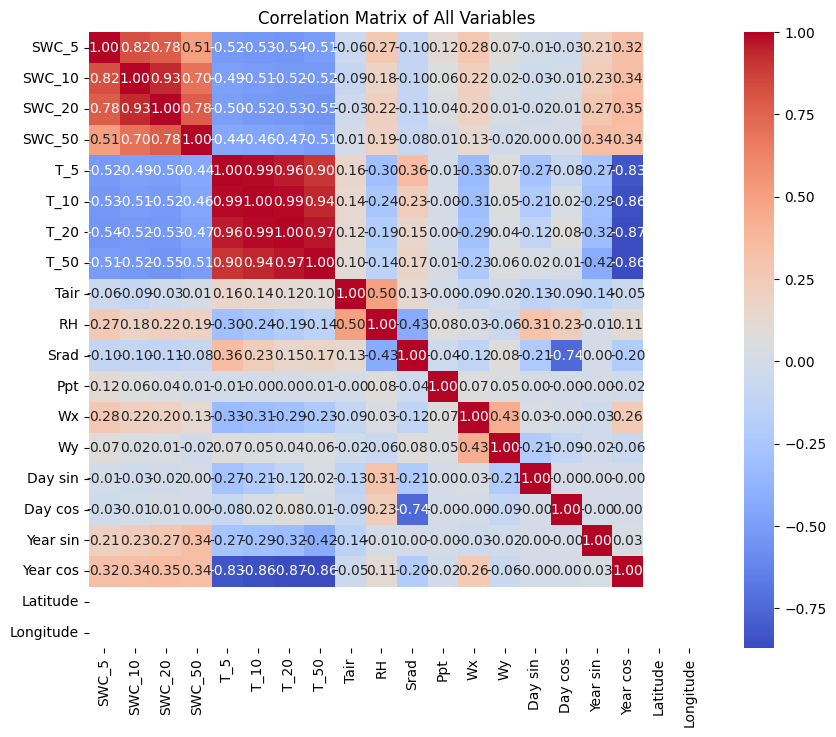

In [ ]:
corr_matrix = full_data.corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True)
plt.title('Correlation Matrix of All Variables')
plt.show()

In [ ]:
data['Ppt_rolling_mean_3h'] = data['Ppt'].rolling(window=3).mean()  # 3-hour rolling mean
data['Ppt_rolling_sum_24h'] = data['Ppt'].rolling(window=24).sum()  # 24-hour rolling sum

# Create lag features for 'Ppt'
for lag in range(1, 25):  # 24-hour lags
    data[f'Ppt_lag_{lag}h'] = data['Ppt'].shift(lag)


data.dropna(inplace=True)


In [ ]:
X = data.drop(['Ppt', 'Date'], axis=1)
y = data['Ppt']
dates = data['Date']

# Split data into training and testing sets
X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(X, y, dates, test_size=0.2, random_state=42)

# Initialize and train the Gradient Boosting Regressor
model = GradientBoostingRegressor()
model.fit(X_train, y_train)

# Predict on the testing set
predictions = model.predict(X_test)

# Calculate error metrics
mae = mean_absolute_error(y_test, predictions)
rmse = mean_squared_error(y_test, predictions, squared=False)

print(f'Mean Absolute Error: {mae}')
print(f'Root Mean Squared Error: {rmse}')

#cross validation
num_folds = 5
y_pred_cv = cross_val_predict(model, X_train, y_train, cv=num_folds)

mae_cv = mean_absolute_error(y_train, y_pred_cv)
rmse_cv = mean_squared_error(y_train, y_pred_cv, squared=False)

print(f'Mean Absolute Error (CV): {mae_cv}')
print(f'Root Mean Squared Error (CV): {rmse_cv}')

Mean Absolute Error: 1.1533484433774089e-05
Root Mean Squared Error: 0.00042822632601947073
Mean Absolute Error (CV): 1.4478006286358084e-05
Root Mean Squared Error (CV): 0.0006364150219029736


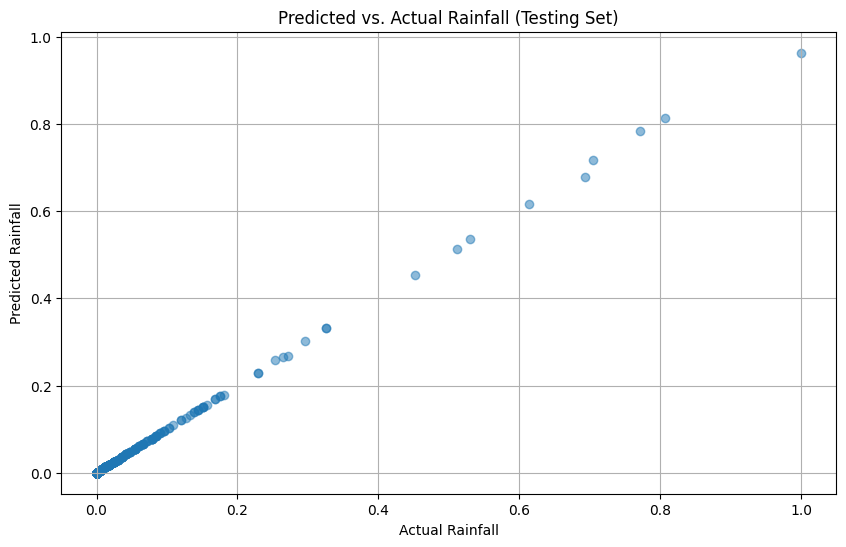

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.5)
plt.xlabel('Actual Rainfall')
plt.ylabel('Predicted Rainfall')
plt.title('Predicted vs. Actual Rainfall (Testing Set)')
plt.grid(True)
plt.show()

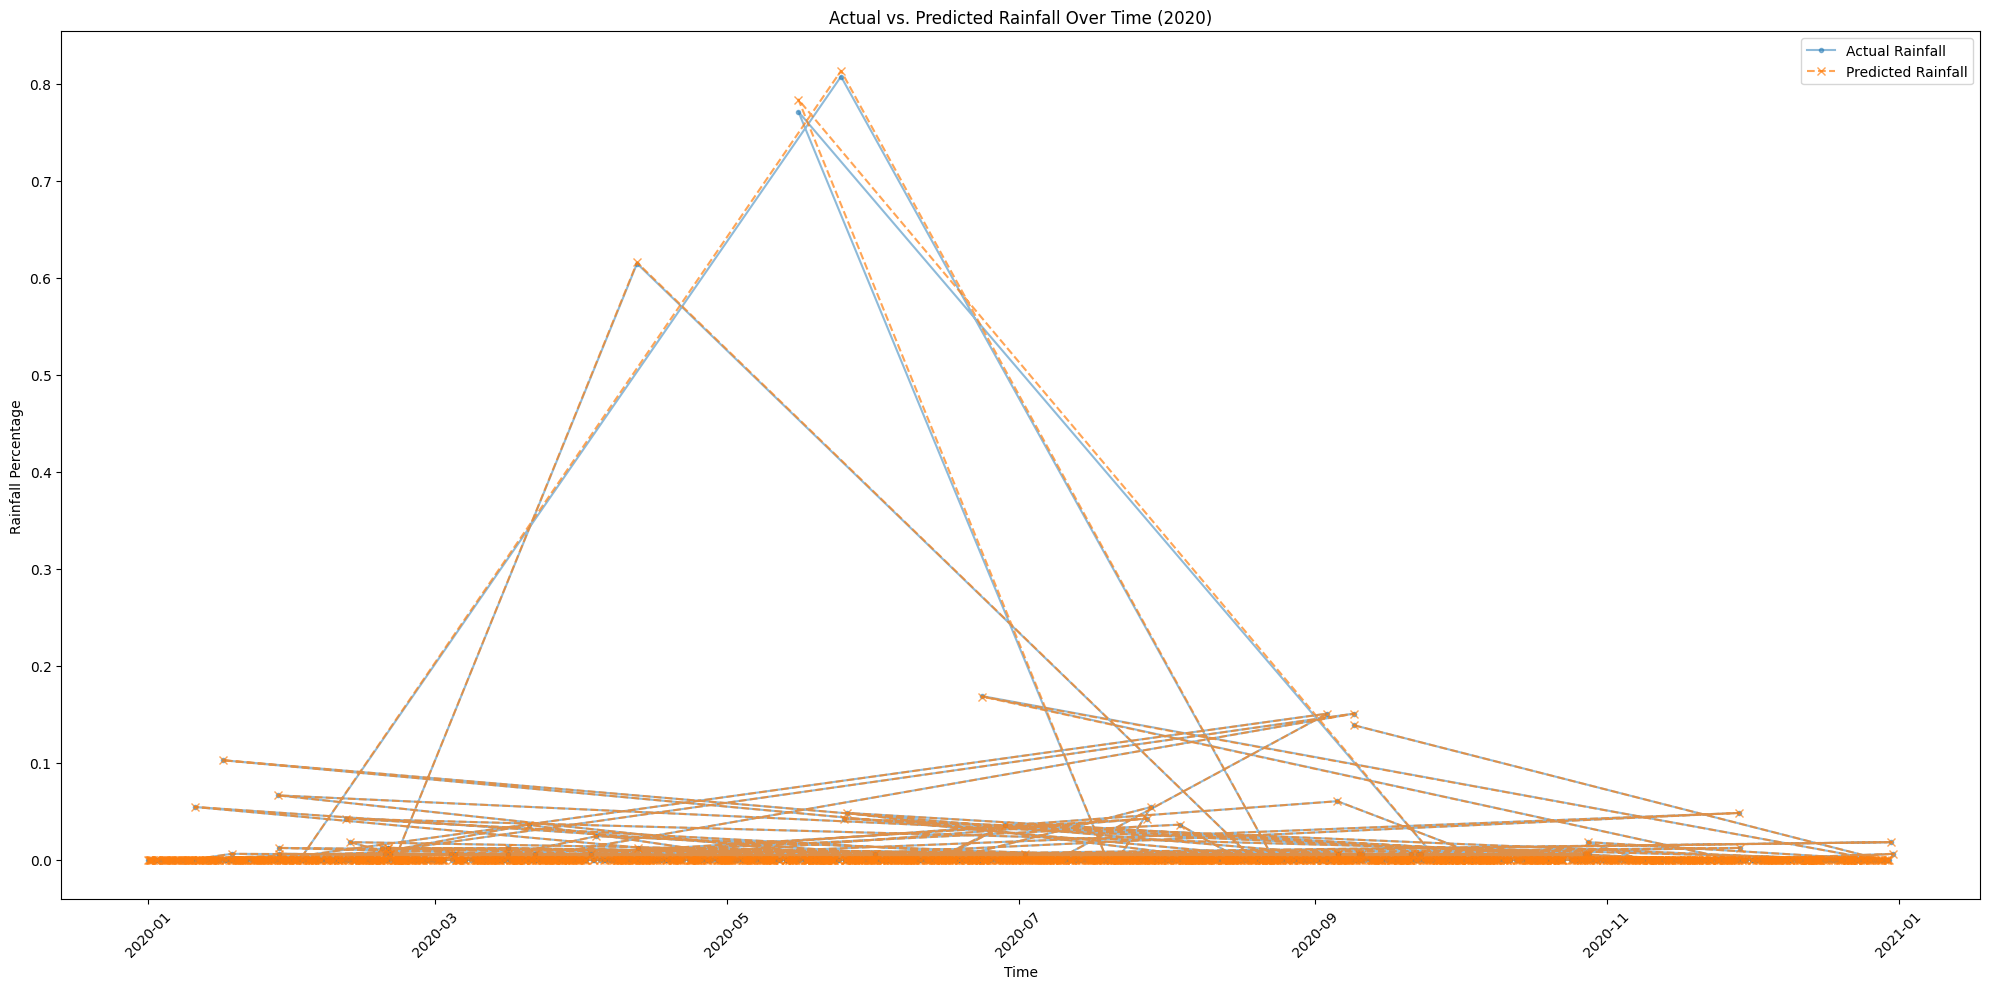

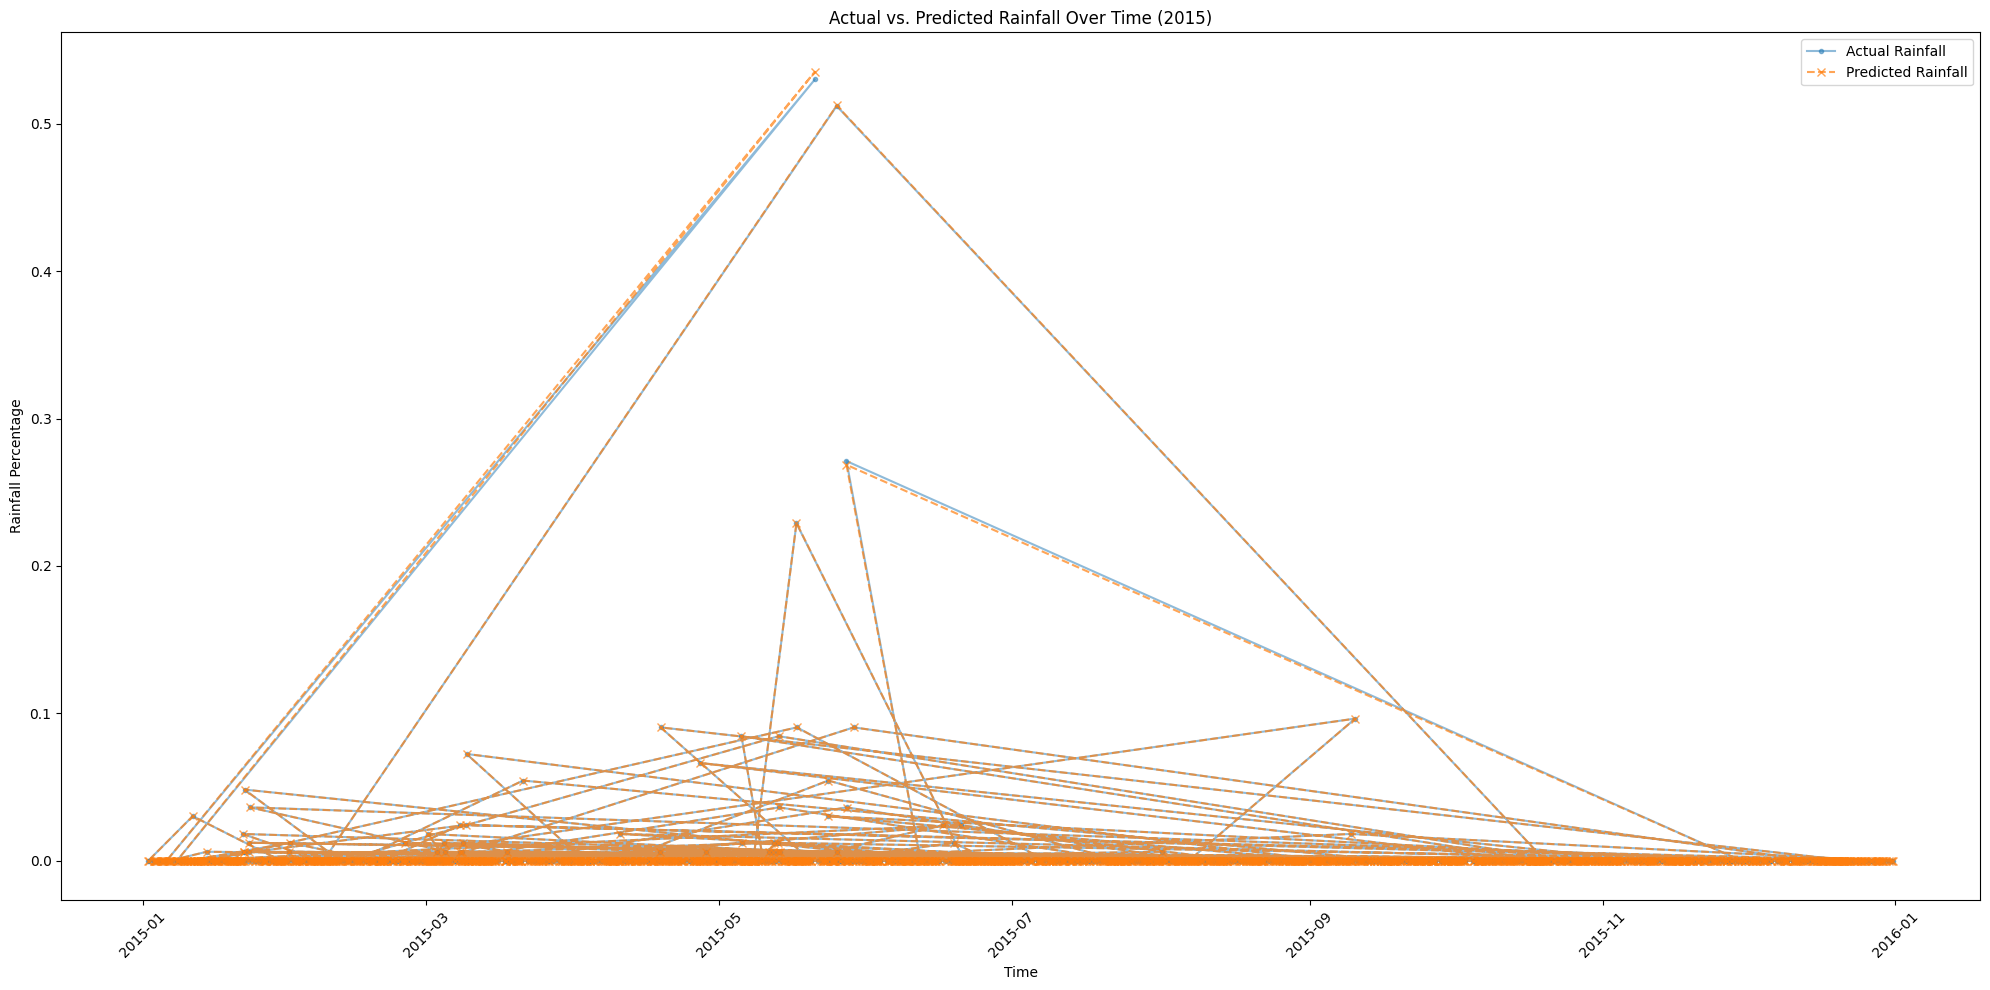

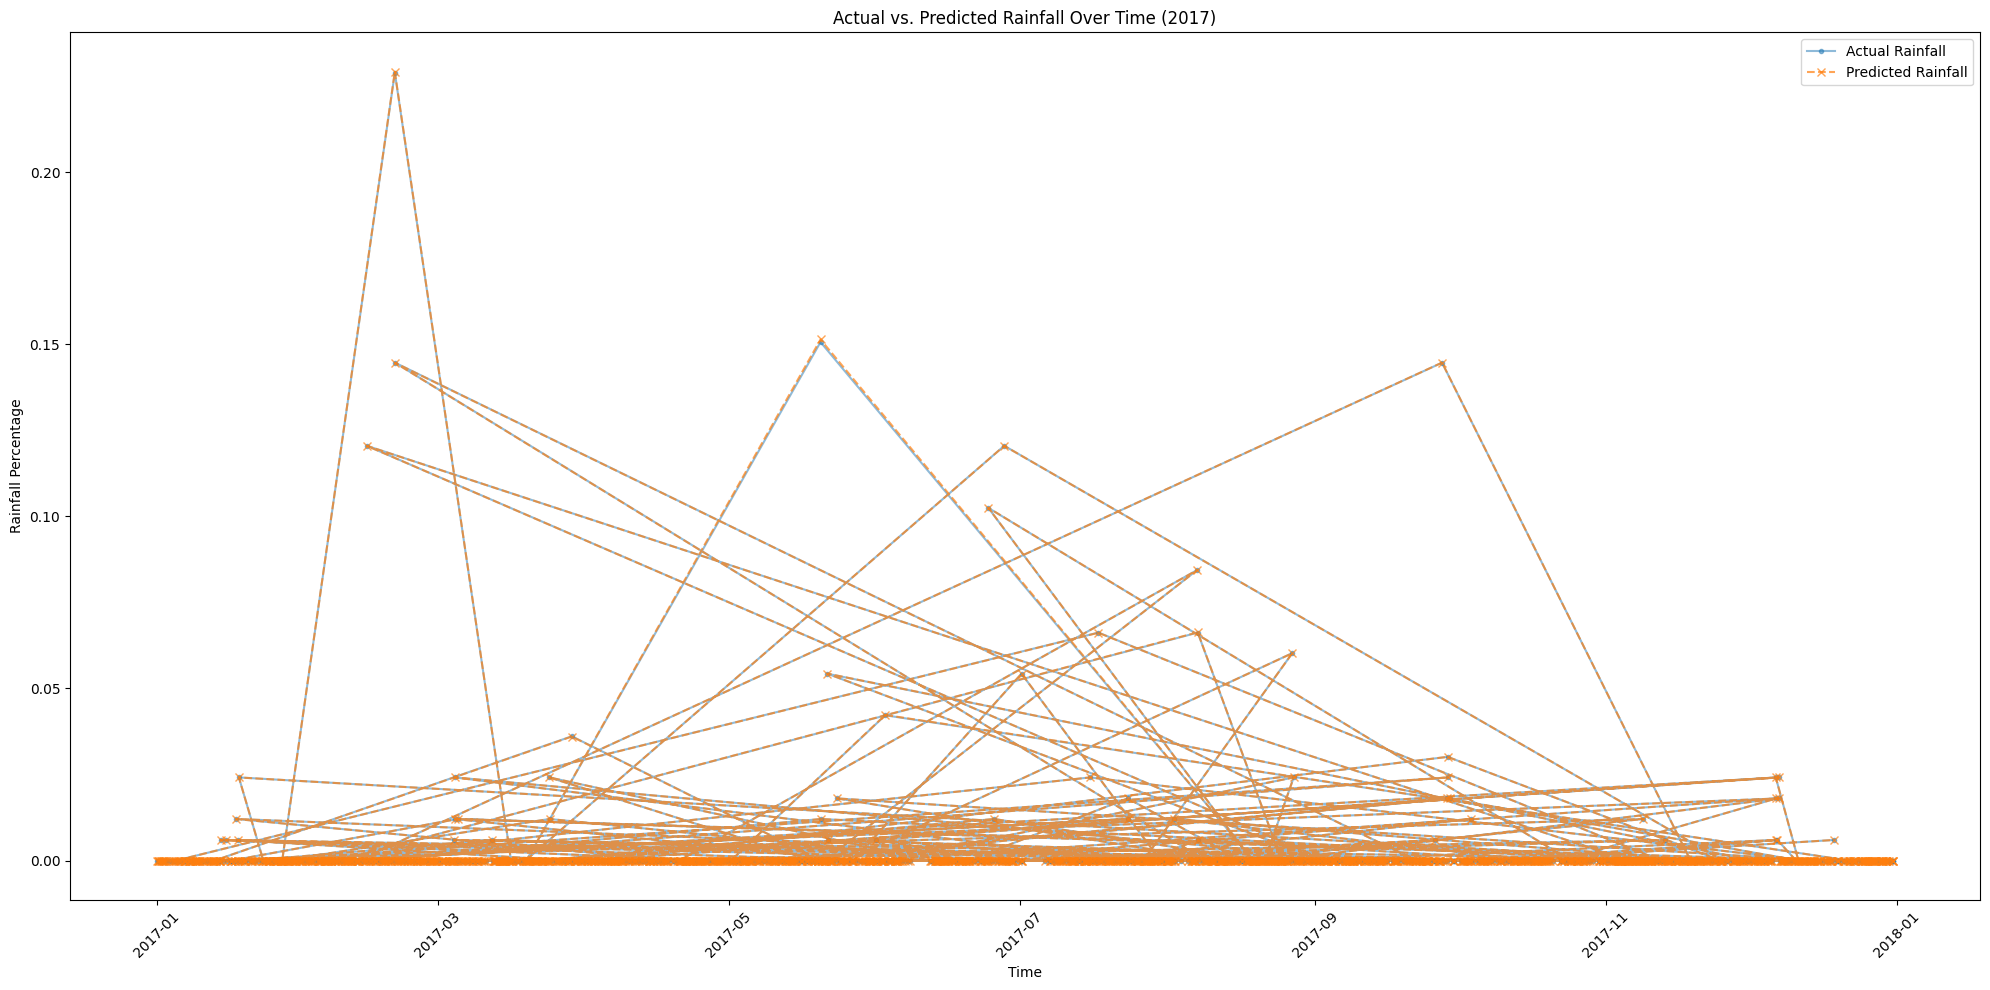

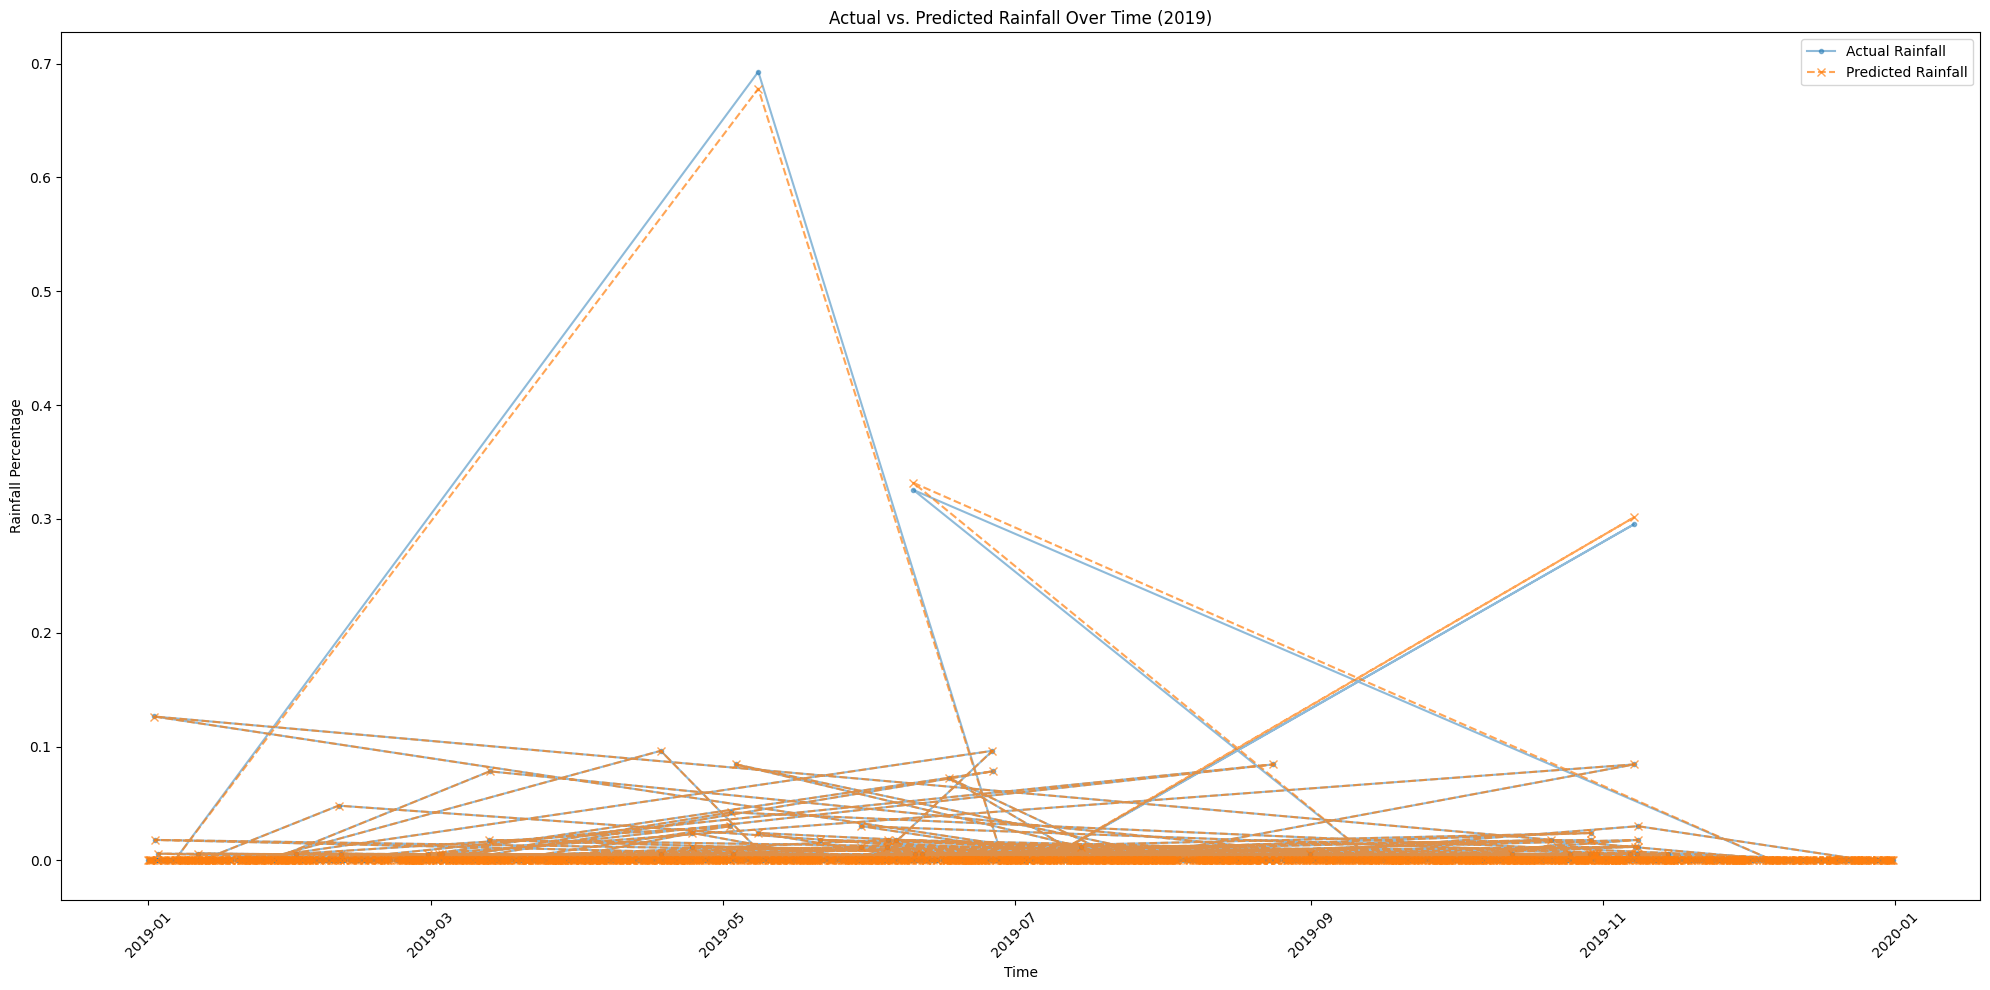

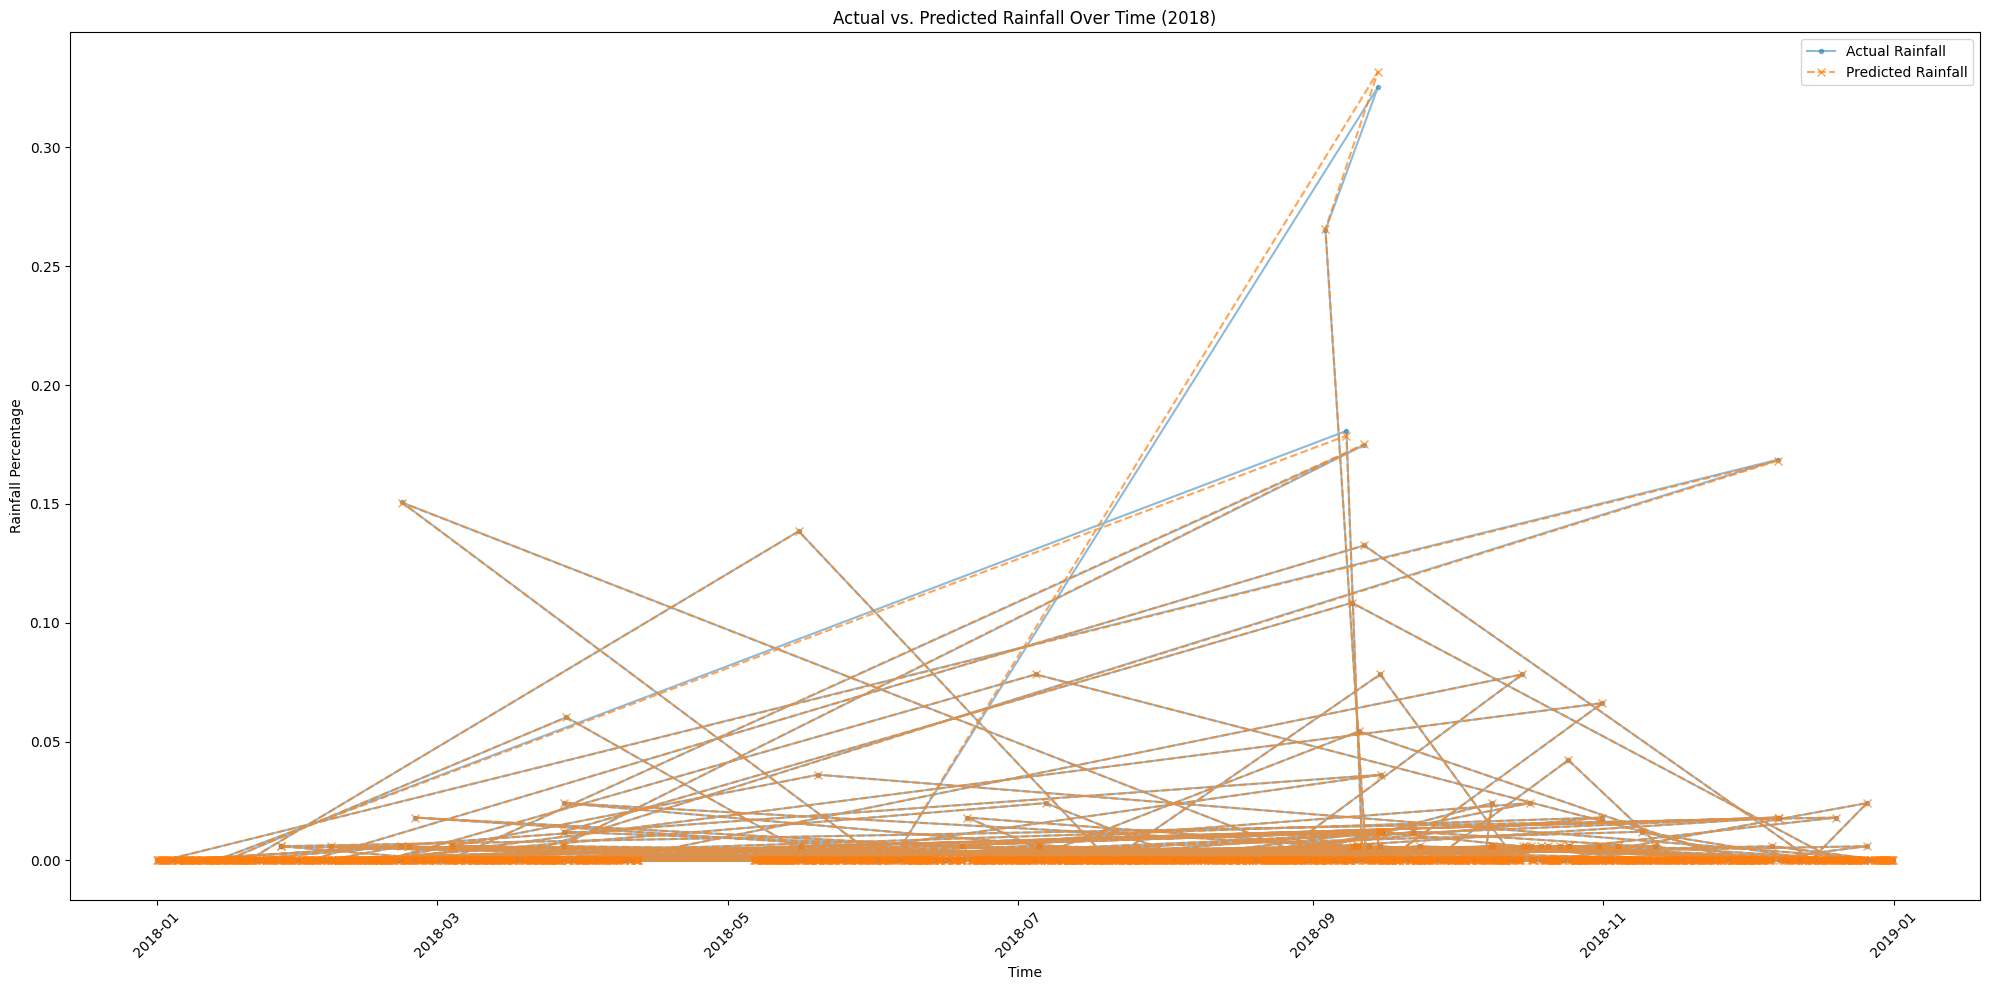

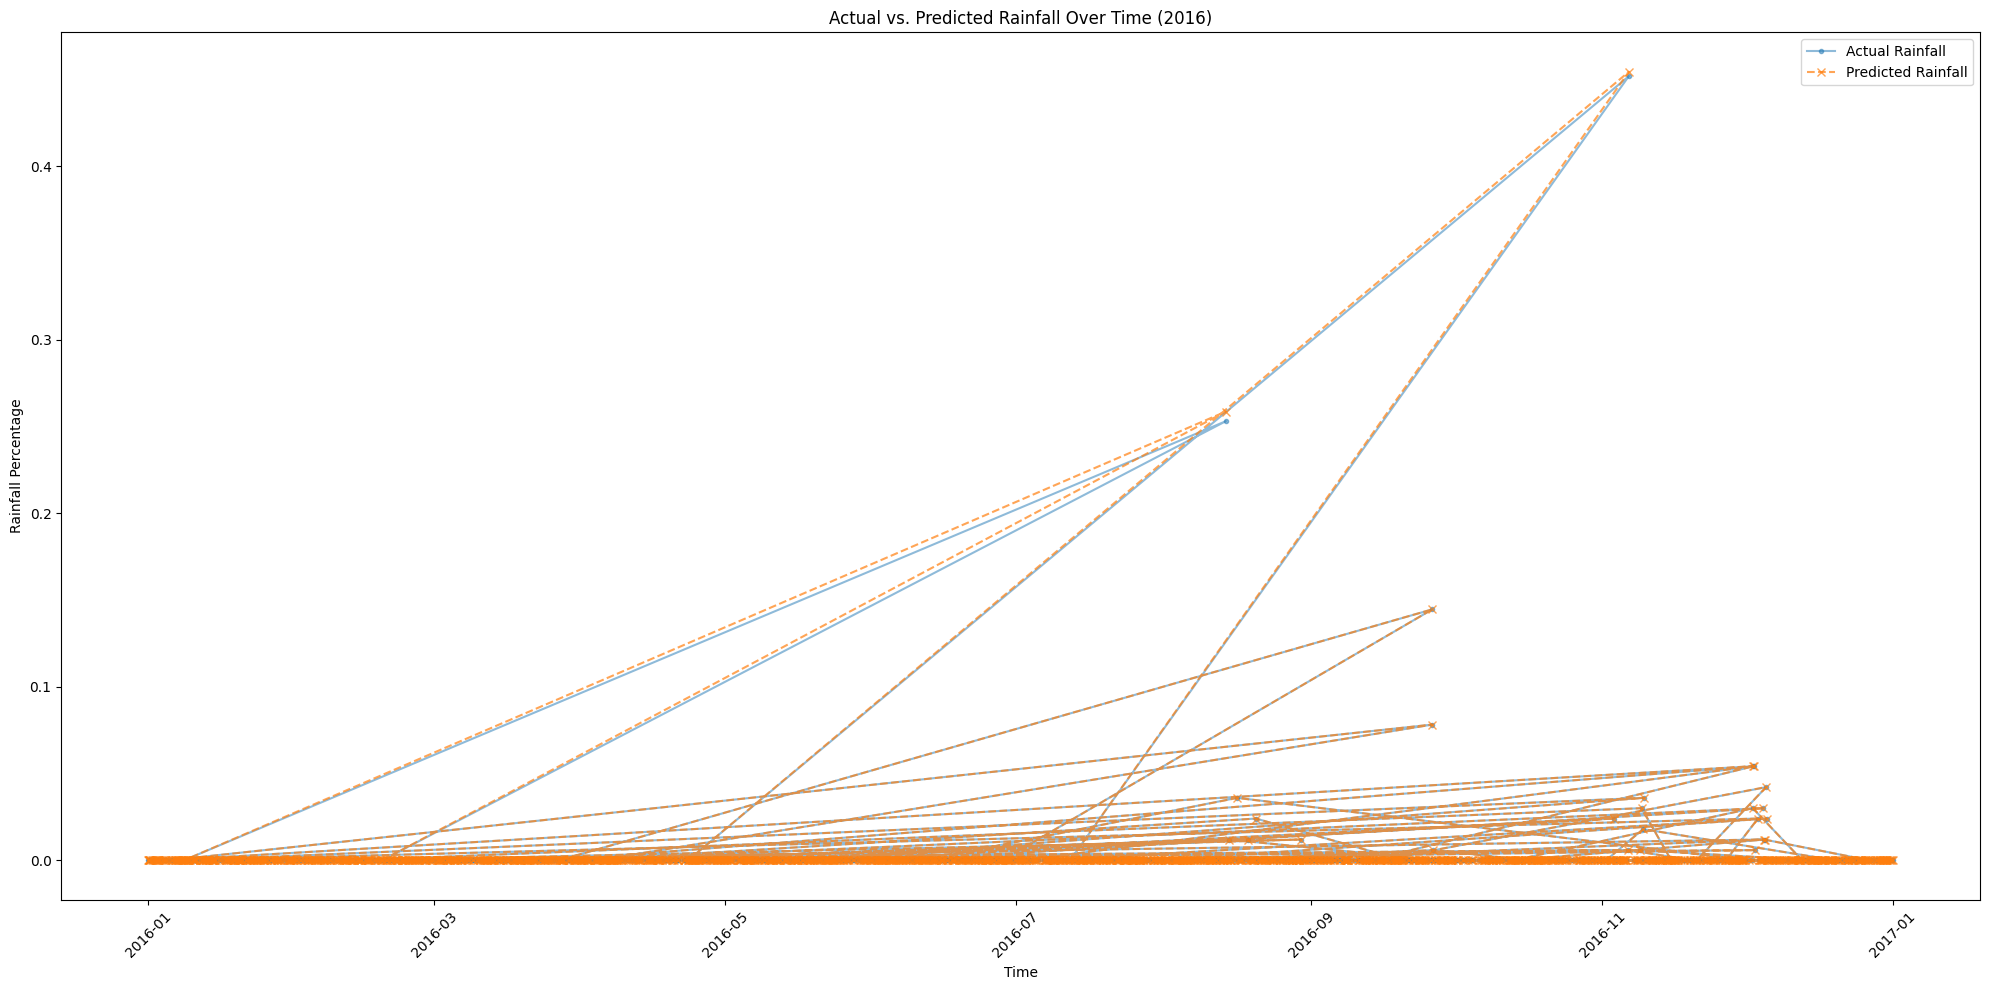

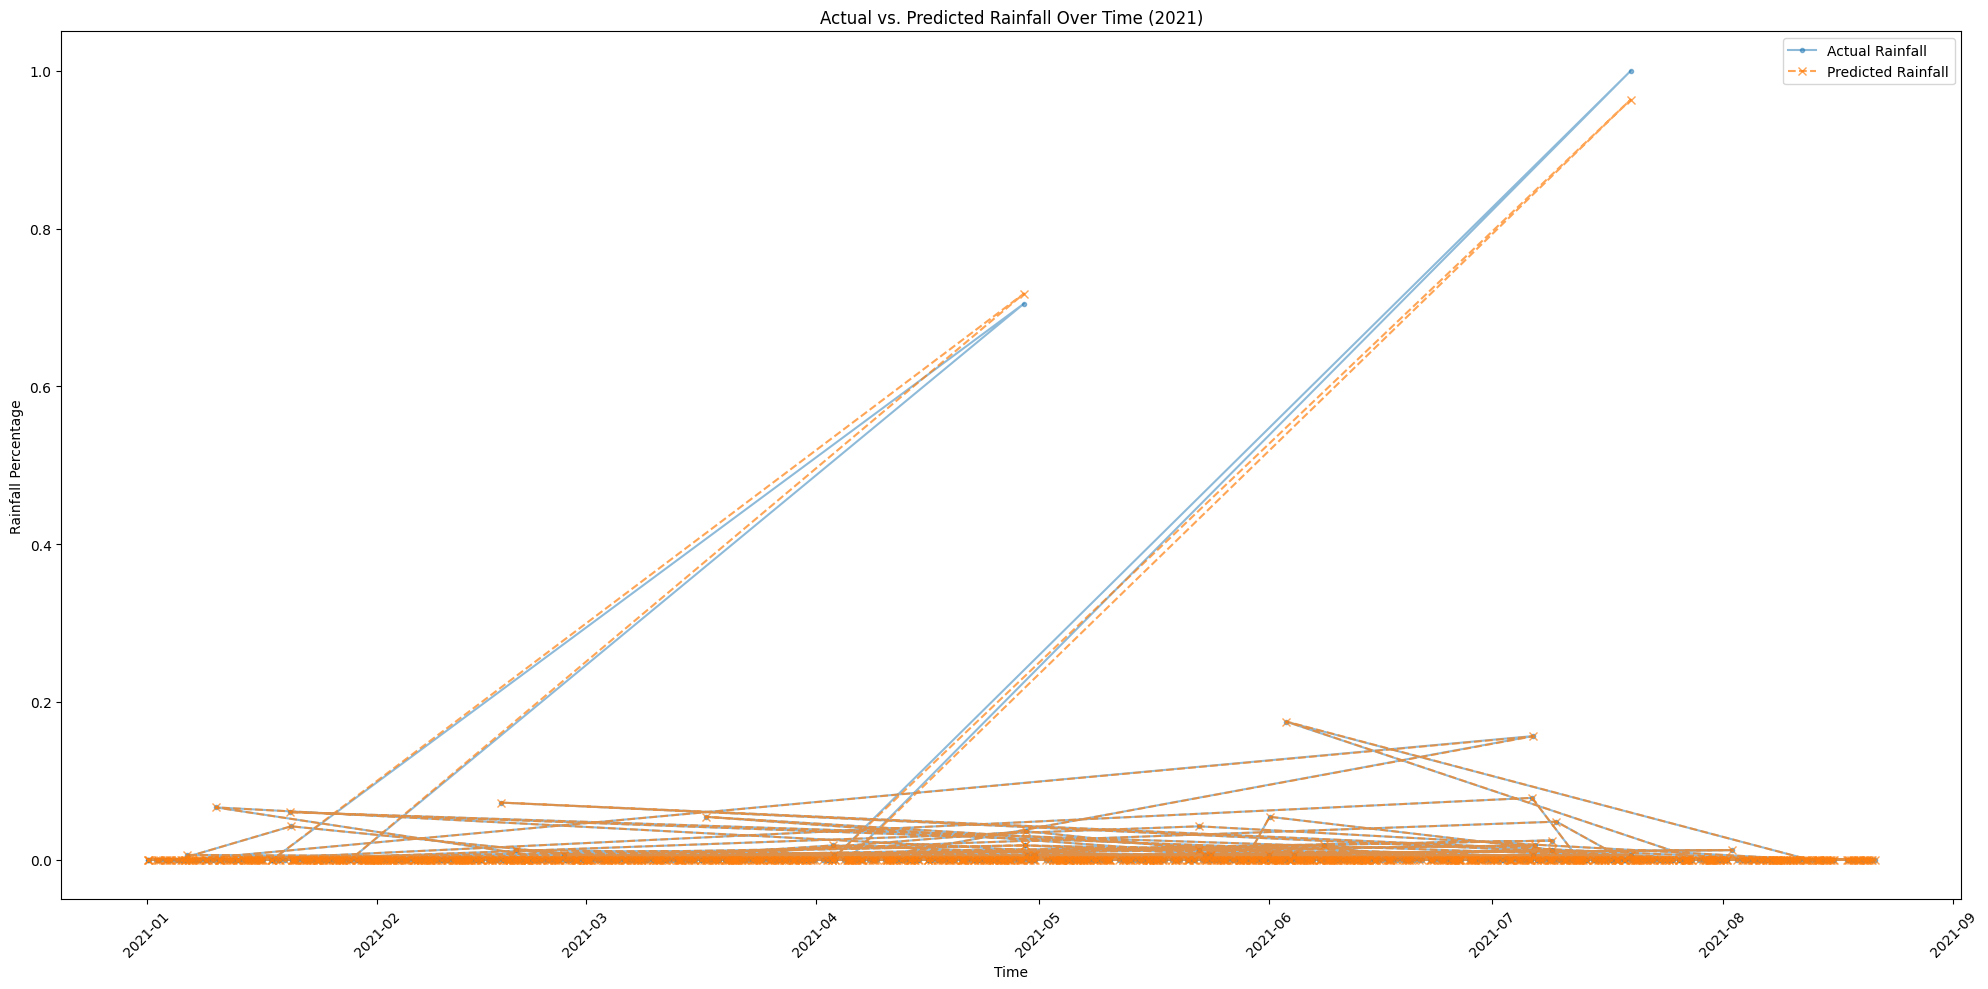

In [ ]:
dates_test = pd.to_datetime(dates_test)

years = dates_test.dt.year.unique()

# Loop through each year and create a separate plot
for year in years:
    # Filter the data for the current year
    mask = dates_test.dt.year == year
    dates_year = dates_test[mask]
    y_test_year = y_test[mask]
    predictions_year = predictions[mask]

    plt.figure(figsize=(20, 10))

    # Create the plot for the cur year
    plt.plot(dates_year, y_test_year, label='Actual Rainfall', marker='.', linestyle='-', alpha=0.5)
    plt.plot(dates_year, predictions_year, label='Predicted Rainfall', marker='x', linestyle='--', alpha=0.7)
    plt.xlabel('Time')
    plt.ylabel('Rainfall Percentage')
    plt.title(f'Actual vs. Predicted Rainfall Over Time ({year})')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#Exponential Smoothing

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


RMSE: 0.0027822272614420403


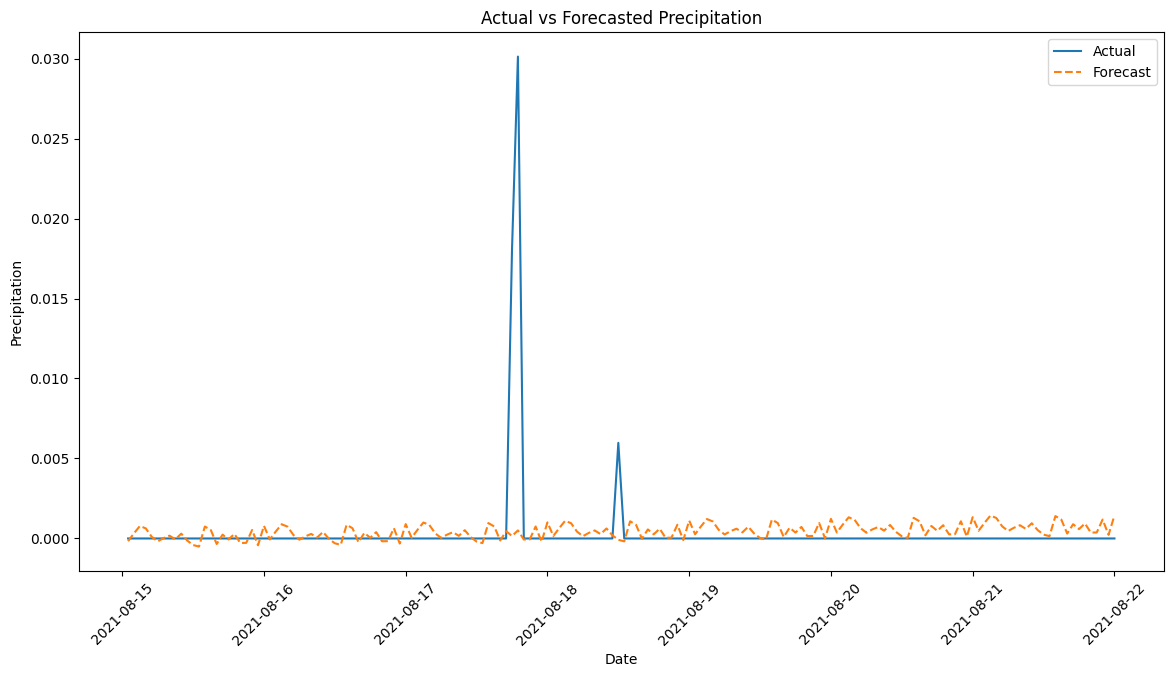

In [ ]:
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)
time_series = data['Ppt']

train = time_series[:-7*24]
test = time_series[-7*24:]
model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=24).fit()

# Forecast the next 7 days
forecast = model.forecast(steps=7*24)

# Calculate RMSE
rmse = sqrt(mean_squared_error(test, forecast))
print(f"RMSE: {rmse}")

# Plotting the actual and forecasted values
plt.figure(figsize=(14, 7))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Forecast', linestyle='--')
plt.title('Actual vs Forecasted Precipitation')
plt.xlabel('Date')
plt.ylabel('Precipitation')
plt.legend()
plt.xticks(rotation=45)
plt.show()

RMSE: 0.0027475094673233102


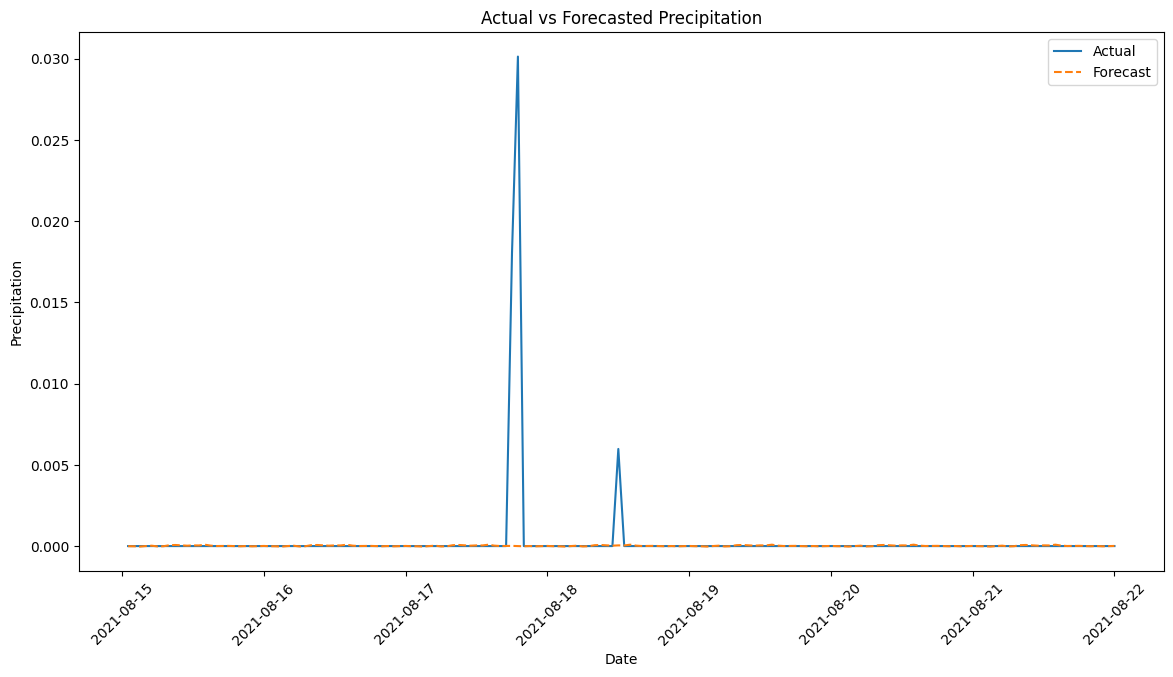

In [ ]:
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Ensure all data is positive by adding a constant
data['Ppt_positive'] = data['Ppt'] + 1 - data['Ppt'].min()

# Apply Box-Cox transformation
time_series_transformed, lambda_val = boxcox(data['Ppt_positive'])

# Split the data
train = time_series_transformed[:-7*24]
test = data['Ppt'][-7*24:]

# Fit the model
model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=24).fit()

# Forecast the next 7 days
forecast_transformed = model.forecast(steps=7*24)

# Invert the Box-Cox transformation
forecast = inv_boxcox(forecast_transformed, lambda_val) - (1 - data['Ppt'].min())

# Calculate RMSE
rmse = sqrt(mean_squared_error(test, forecast))
print(f"RMSE: {rmse}")

# Plotting
plt.figure(figsize=(14, 7))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Forecast', linestyle='--')
plt.title('Actual vs Forecasted Precipitation')
plt.xlabel('Date')
plt.ylabel('Precipitation')
plt.legend()
plt.xticks(rotation=45)
plt.show()

#Data normalization and LSTM

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
data['timestamp'] = data['Date'].astype('int64') // 1e9
data.drop(columns=['Date'], inplace=True)
numeric_features = data.select_dtypes(include=[np.number])
data[numeric_features.columns] = scaler.fit_transform(numeric_features)

In [ ]:
#method to create sequences for LSTM input
def create_sequences(data, n_input, n_output):
    X, y = [], []
    for i in range(len(data)):
        # find the end of this pattern
        end_ix = i + n_input
        out_end_ix = end_ix + n_output
        # check if we are beyond the dataset
        if out_end_ix > len(data):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = data[i:end_ix], data[end_ix:out_end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

n_input = 72  # Last 3 days
n_output = 120  # Next 5 days
X, y = create_sequences(data.values.flatten(), n_input, n_output)

In [ ]:
model = Sequential([
    LSTM(50, activation='relu', input_shape=(n_input, 1)),
    Dense(120, activation='sigmoid')
])
model.compile(optimizer='adam', loss='mse')

In [ ]:
model.fit(X, y, epochs=10, validation_split=0.2, batch_size=64)


Epoch 1/10
21494/21494 [==============================] - 828s 38ms/step - loss: 0.0241 - val_loss: 0.0434
Epoch 2/10
21494/21494 [==============================] - 815s 38ms/step - loss: 0.0238 - val_loss: 0.0434
Epoch 3/10
21494/21494 [==============================] - 824s 38ms/step - loss: 0.0238 - val_loss: 0.0434
Epoch 4/10
21494/21494 [==============================] - 819s 38ms/step - loss: 0.0238 - val_loss: 0.0434
Epoch 5/10
21494/21494 [==============================] - 820s 38ms/step - loss: 0.0238 - val_loss: 0.0434
Epoch 6/10
21494/21494 [==============================] - 820s 38ms/step - loss: 0.0238 - val_loss: 0.0434
Epoch 7/10
21494/21494 [==============================] - 820s 38ms/step - loss: 0.0238 - val_loss: 0.0434
Epoch 8/10
21494/21494 [==============================] - 815s 38ms/step - loss: 0.0238 - val_loss: 0.0434
Epoch 9/10
21494/21494 [==============================] - 824s 38ms/step - loss: 0.0238 - val_loss: 0.0434
Epoch 10/10
21494/21494 [============

In [ ]:
predictions = model.predict(X_test)

NameError: name 'model' is not defined